# Laser Step-Down: Settling to New Steady States
**Scenario:** the imaging laser power is stepped down through a sequence of setpoints
(`lab_utils/laser_step_down.py`), each held for an extended dwell. Radiation-pressure
torque tracks laser power, so at each step the disk's spin frequency relaxes from the
previous steady state to a new (generally lower) one — the same physics as
`spindown_steadystate.ipynb`'s single beamsplitter step, but repeated automatically
across ~4 days (2026-07-05 to 2026-07-09) with no logged record of exact step times.

**Method:**
1. Detect the actual step times/levels from the PD trace itself (no offset-setpoint
   channel was exported for this run).
2. Bandpass + Hilbert transform on LES YAW to get instantaneous spin frequency.
3. Fit `f(t) = f_ss + A * exp(-gamma*t)` at each transition, same model as
   `spindown_steadystate.ipynb`.
4. Save the detected step table for `laser_stepdown_stability.ipynb` (PSD snapshots /
   long-term stability), so that notebook doesn't need to redetect steps.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
from scipy.signal import decimate, butter, sosfiltfilt, hilbert
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d
import csv

/Users/mollywatts/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# GPS -> UTC: GPS epoch is Jan 6 1980; 18 leap seconds as of 2025
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

def dt_to_gps(dt):
    return dt.timestamp() - GPS_UNIX_OFFSET

# Each channel is split across two back-to-back export files (second starts exactly
# where the first ends), covering 2026-07-05 21:46 UTC -> 2026-07-09 20:05 UTC.
PD_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467582390_1467662710.h5',
]
YAW_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1467582390_1467662710.h5',
]
# PIT is used only as an independent cross-check in Section 4.5 (a different readout
# axis of the same rotating disk -- if both channels agree on a frequency, it's real
# rotation, not a channel-specific artifact).
PIT_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_pit/Y1_RDS-LES_PIT_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_pit/Y1_RDS-LES_PIT_IN1_DQ_1467582390_1467662710.h5',
]

STEP_TABLE_CSV = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_stepdown_steps.csv'

# Correspondence between detected plateaus and the operator's step-down log (48 steps
# total). Originally only the three ~18-20 h holds were resolvable at a 5 h minimum
# duration; lowering that (Section 2) picks up the shorter intentional sub-steps too
# (tens of minutes to ~2.5 h), most of which also match a specific logged wait time
# closely. A few short, closely-spaced levels in the declining tail (see Section 2's
# NOTE) couldn't be matched confidently and are left unlabeled.
STEP_LOG_INFO = {
    2:  dict(counts=1800, power_mw=15.10, log_step='1/48',  log_wait_min=40.8),
    3:  dict(counts=1600, power_mw=12.92, log_step='5/48',  log_wait_min=1192.9),
    4:  dict(counts=1550, power_mw=12.23, log_step='6/48',  log_wait_min=158.7),
    5:  dict(counts=1500, power_mw=11.46, log_step='7/48',  log_wait_min=72.6),
    6:  dict(counts=1400, power_mw=10.01, log_step='9/48',  log_wait_min=89.1),
    7:  dict(counts=1300, power_mw=8.49,  log_step='11/48', log_wait_min=1086.0),
    8:  dict(counts=1200, power_mw=7.09,  log_step='13/48', log_wait_min=132.8),
    11: dict(counts=1000, power_mw=3.41,  log_step='17/48', log_wait_min=1053.6),
}

def step_label(i, s):
    info = STEP_LOG_INFO.get(i)
    if info:
        return f"{info['counts']} counts (~{info['power_mw']:.2f} mW)"
    if i <= 1:
        return f"PD={s['pd_level']:.0f} (pre-sequence, before log step 1/48)"
    return f"PD={s['pd_level']:.0f} (unmatched -- see Section 2 note)"

## 1. Overview: PD Trace (Full ~4-Day Span)
Strided read (1 Hz effective) across both files — enough resolution to see the power
steps, far too coarse for the spin-frequency work in Section 3.

PD: 339,520 points  2026-07-05 21:46:12+00:00 -> 2026-07-09 20:04:51+00:00
span: 94.31 h


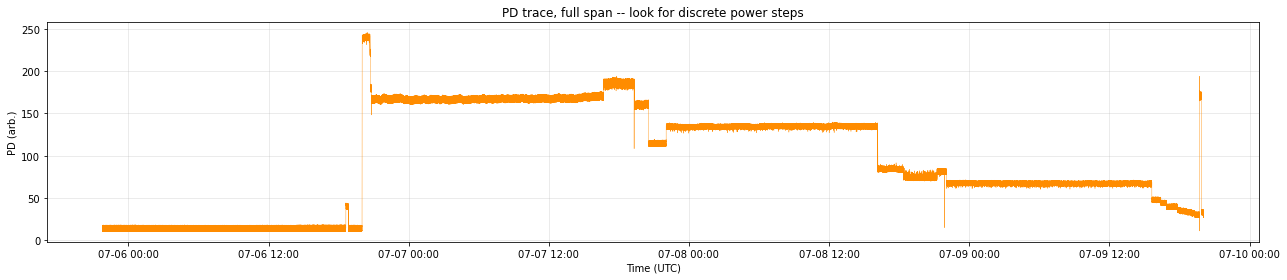

In [3]:
def load_strided_multi(files, stride):
    """Strided read across one or more back-to-back HDF5 exports (no anti-alias
    filter -- for visual inspection / step-level detection only)."""
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            for gps0, ix, n in zip(segs, idxs, lens):
                y_seg = dset[ix: ix + n: stride].astype(np.float32)
                t_seg = gps0 + np.arange(len(y_seg)) * stride / fs
                t_list.append(t_seg)
                y_list.append(y_seg)
    t = np.concatenate(t_list)
    y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

STRIDE_PD = 1024  # 1024 Hz -> 1 Hz effective
t_pd, y_pd = load_strided_multi(PD_FILES, STRIDE_PD)
print(f"PD: {len(y_pd):,} points  {gps_to_dt(t_pd[0])} -> {gps_to_dt(t_pd[-1])}")
print(f"span: {(t_pd[-1] - t_pd[0]) / 3600:.2f} h")

fig, ax = plt.subplots(figsize=(18, 4))
ax.plot([gps_to_dt(t) for t in t_pd], y_pd, linewidth=0.4, color='darkorange')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('PD (arb.)')
ax.set_title('PD trace, full span -- look for discrete power steps')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Step Detection
No offset-setpoint channel was exported for this run, so steps are detected directly
from the PD trace:
1. Bin into 5-minute chunks; a chunk is "stable" if its std is small (< `STD_THRESH`).
2. Group consecutive stable chunks whose medians agree within `LEVEL_TOL` into one
   plateau.
3. Keep only plateaus lasting >= `MIN_DURATION_H` -- this discards the brief
   (tens of minutes to a few hours) overshoot/settling excursions between steps,
   which show up as either non-stable (high std) or short-lived stable chunks.

In [4]:
BIN_S          = 300   # 5 min bins
STD_THRESH     = 5.0   # PD units -- chunks noisier than this are mid-transition
LEVEL_TOL      = 4.0   # PD units -- tight enough to resolve closely-spaced low-power
                        # sub-steps (e.g. 47 vs 39 vs 33) without fragmenting the long
                        # high-power plateaus (which stay far more than this apart)
MIN_DURATION_H = 0.3   # lowered from 5.0 h: the operator's log shows most of the 48
                        # steps were genuinely held tens of minutes, not hours -- a 5 h
                        # floor only caught the three longest (~18-20 h) holds and threw
                        # the real shorter steps away as "transition"

t0 = t_pd[0]
bin_idx = ((t_pd - t0) // BIN_S).astype(int)
n_bins = bin_idx.max() + 1
bin_med = np.full(n_bins, np.nan)
bin_std = np.full(n_bins, np.nan)
bin_t0  = t0 + np.arange(n_bins) * BIN_S
for b in range(n_bins):
    m = bin_idx == b
    if m.sum() > 0:
        bin_med[b] = np.median(y_pd[m])
        bin_std[b] = y_pd[m].std()

stable = (bin_std < STD_THRESH) & np.isfinite(bin_med)

segments = []
cur_start, cur_levels = None, []
for b in range(n_bins):
    if stable[b]:
        if cur_start is None:
            cur_start, cur_levels = b, [bin_med[b]]
        elif abs(bin_med[b] - np.median(cur_levels)) < LEVEL_TOL:
            cur_levels.append(bin_med[b])
        else:
            segments.append((cur_start, b - 1, np.median(cur_levels)))
            cur_start, cur_levels = b, [bin_med[b]]
    else:
        if cur_start is not None:
            segments.append((cur_start, b - 1, np.median(cur_levels)))
            cur_start, cur_levels = None, []
if cur_start is not None:
    segments.append((cur_start, n_bins - 1, np.median(cur_levels)))

steps = []
for s0, s1, lvl in segments:
    dur_h = (s1 - s0 + 1) * BIN_S / 3600
    if dur_h >= MIN_DURATION_H:
        steps.append(dict(
            pd_level=lvl,
            t_start_gps=bin_t0[s0],
            t_end_gps=bin_t0[s1] + BIN_S,
            duration_h=dur_h,
        ))

print(f"{len(steps)} steady-state plateaus detected (>= {MIN_DURATION_H} h):\n")
for i, s in enumerate(steps):
    print(f"  [{i:2d}] {step_label(i, s):46s} "
          f"{gps_to_dt(s['t_start_gps'])} -> {gps_to_dt(s['t_end_gps'])}  ({s['duration_h']*60:.0f} min)")

print("\nNOTE: steps [0]-[1] predate log step [1/48] entirely (both ~PD 14, split only"
      " by a brief\nunstable blip -- not a commanded change). Steps [9], [10], [12]-[14]"
      " are real sub-steps in\nthe declining tail (log steps ~14/48-27/48, 1150->810"
      " counts) but sit too close together\nin PD level for this method to confidently"
      " assign each one a specific logged count value\n(a couple of adjacent short logged"
      " steps likely land within LEVEL_TOL of each other down\nthere) -- they're fit in"
      " Section 4 like everything else, just labeled by PD level instead\nof counts/mW."
      " The data ends mid-transition after the last plateau without reaching a\nnew"
      " stable level; that final decline is shown in the plots for context but isn't a"
      " completed step.")

15 steady-state plateaus detected (>= 0.3 h):

  [ 0] PD=14 (pre-sequence, before log step 1/48)     2026-07-05 21:46:12+00:00 -> 2026-07-06 18:36:12+00:00  (1250 min)
  [ 1] PD=14 (pre-sequence, before log step 1/48)     2026-07-06 18:51:12+00:00 -> 2026-07-06 19:56:12+00:00  (65 min)
  [ 2] 1800 counts (~15.10 mW)                        2026-07-06 20:01:12+00:00 -> 2026-07-06 20:41:12+00:00  (40 min)
  [ 3] 1600 counts (~12.92 mW)                        2026-07-06 20:51:12+00:00 -> 2026-07-07 16:41:12+00:00  (1190 min)
  [ 4] 1550 counts (~12.23 mW)                        2026-07-07 16:46:12+00:00 -> 2026-07-07 19:16:12+00:00  (150 min)
  [ 5] 1500 counts (~11.46 mW)                        2026-07-07 19:21:12+00:00 -> 2026-07-07 20:31:12+00:00  (70 min)
  [ 6] 1400 counts (~10.01 mW)                        2026-07-07 20:36:12+00:00 -> 2026-07-07 22:01:12+00:00  (85 min)
  [ 7] 1300 counts (~8.49 mW)                         2026-07-07 22:06:12+00:00 -> 2026-07-08 16:06:12+00:00  (1080

### Correspondence with the operator's step-down log

The step-down script logs 48 commanded levels with wait times. At a 5 h minimum
duration, only the three ~18-20 h holds were resolvable; lowering the minimum
(`MIN_DURATION_H = 0.3`) picks up the shorter intentional steps too, and most of
those also match a specific logged wait time closely:

| log step | counts | power | logged wait | detected step | detected duration |
|---|---|---|---|---|---|
| 1/48  | 1800 | ~15.10 mW | 40.8 min             | [2]  | 40 min |
| 5/48  | 1600 | ~12.92 mW | 1192.9 min = 19.88 h | [3]  | 19.8 h |
| 6/48  | 1550 | ~12.23 mW | 158.7 min            | [4]  | 150 min |
| 7/48  | 1500 | ~11.46 mW | 72.6 min             | [5]  | 70 min |
| 9/48  | 1400 | ~10.01 mW | 89.1 min             | [6]  | 85 min |
| 11/48 | 1300 | ~8.49 mW  | 1086.0 min = 18.10 h | [7]  | 18.0 h |
| 13/48 | 1200 | ~7.09 mW  | 132.8 min            | [8]  | 130 min |
| 17/48 | 1000 | ~3.41 mW  | 1053.6 min = 17.56 h | [11] | 17.5 h |

(Log steps 8/48, 10/48 = 1450, 1350 counts had a logged wait of 0.0 min -- correctly
no detected plateau in between. Steps 12/48+ get into the declining tail where levels
sit too close together to confidently assign individual log entries -- see Section 2's
NOTE.)

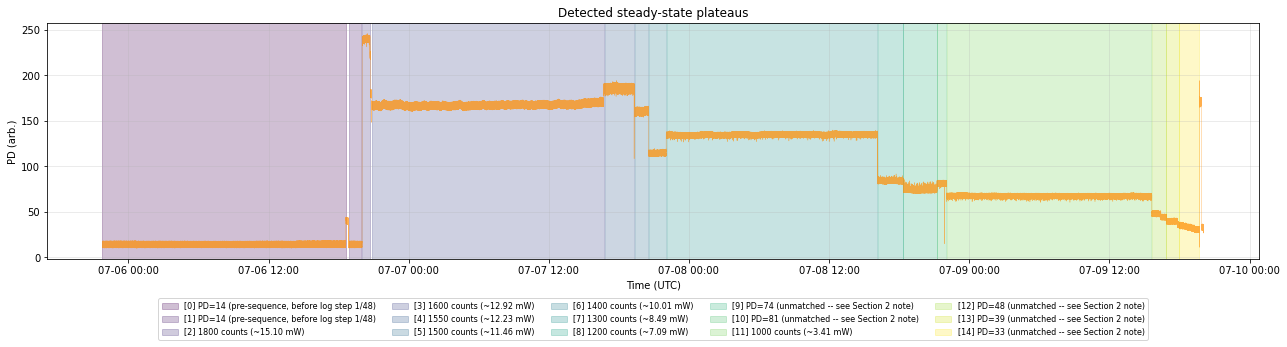

In [5]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot([gps_to_dt(t) for t in t_pd], y_pd, linewidth=0.4, color='darkorange', alpha=0.7)
colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))
for i, s in enumerate(steps):
    ax.axvspan(gps_to_dt(s['t_start_gps']), gps_to_dt(s['t_end_gps']),
               color=colors[i], alpha=0.25, label=f"[{i}] {step_label(i, s)}")
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('PD (arb.)')
ax.set_title('Detected steady-state plateaus')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.legend(fontsize=8, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. YAW Spin Frequency (Full Span)
Same bandpass -> Hilbert transform -> instantaneous frequency pipeline as
`spindown_20260702.ipynb` / `spindown_steadystate.ipynb`, run across the full
~4-day span at 64 Hz.

In [6]:
def load_channel_multi(files, fs_out=64.0):
    """Decimated read across one or more back-to-back HDF5 exports."""
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            dec  = int(round(fs / fs_out))
            for gps0, ix, n in zip(segs, idxs, lens):
                seg = dset[ix:ix + n].astype(np.float64)
                if dec == 16:
                    seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)
                elif dec > 1:
                    seg = decimate(seg, dec, zero_phase=True)
                t_seg = gps0 + np.arange(len(seg)) / fs_out
                t_list.append(t_seg)
                y_list.append(seg)
    t = np.concatenate(t_list)
    y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

def hilbert_freq(y_filt, fs, smooth_sec=30.0):
    """Return (inst_freq, envelope, dt_half) -- all arrays length N-1, aligned."""
    analytic  = hilbert(y_filt)
    envelope  = np.abs(analytic)
    phase     = np.unwrap(np.angle(analytic))
    dt        = 1.0 / fs
    inst_freq = np.diff(phase) / (2 * np.pi * dt)
    win       = max(1, int(smooth_sec * fs))
    return (uniform_filter1d(inst_freq,     size=win),
            uniform_filter1d(envelope[:-1], size=win),
            dt / 2)

FS_RING = 64.0
# F_HIGH was originally 3.0 Hz ("covers baseline through fastest plateau ~2.7 Hz"), but
# Section 4.5's PSD cross-check (confirmed against the independent PIT channel) found
# the true rotation frequency for several steps (1800/1600/1550/1500 counts) sits at
# 2.3-3.9 Hz -- above that cutoff, so a 4th-order Butterworth wasn't fully rejecting it
# and the Hilbert transform was tracking filter leakage instead of the real signal.
# Widened to clear the highest confirmed rotation frequency (~3.87 Hz) with margin.
F_LOW, F_HIGH = 0.02, 6.0   # Hz
SMOOTH_SEC = 30.0

print("Loading YAW at 64 Hz across the full span (this takes a little while)...")
t_yaw, y_yaw = load_channel_multi(YAW_FILES, fs_out=FS_RING)
print(f"YAW: {len(y_yaw):,} samples  {gps_to_dt(t_yaw[0])} -> {gps_to_dt(t_yaw[-1])}")

sos     = butter(4, [F_LOW, F_HIGH], btype='bandpass', fs=FS_RING, output='sos')
y_yaw_f = sosfiltfilt(sos, y_yaw)
freq_yaw, env_yaw, dt_half = hilbert_freq(y_yaw_f, FS_RING, SMOOTH_SEC)
t_freq_yaw = t_yaw[:-1] + dt_half
print(f"freq range: {freq_yaw.min():.3f} - {freq_yaw.max():.3f} Hz")

Loading YAW at 64 Hz across the full span (this takes a little while)...
YAW: 21,729,280 samples  2026-07-05 21:46:12+00:00 -> 2026-07-09 20:04:51.984375+00:00
freq range: 0.006 - 7.108 Hz


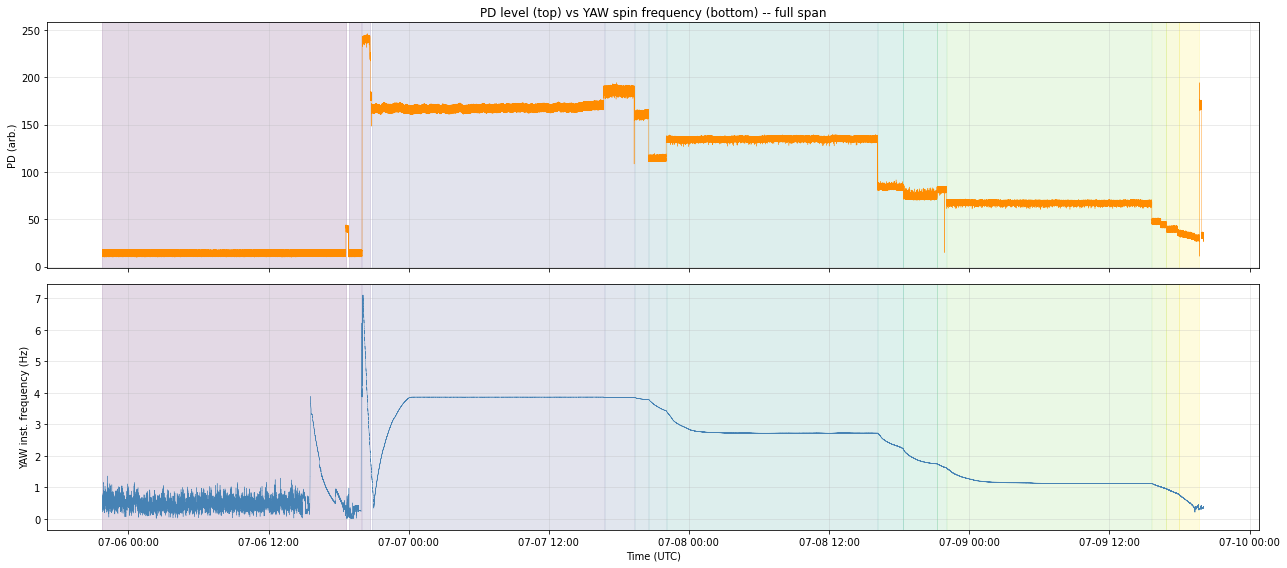

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axes[0].plot([gps_to_dt(t) for t in t_pd], y_pd, linewidth=0.4, color='darkorange')
axes[0].set_ylabel('PD (arb.)')
axes[0].set_title('PD level (top) vs YAW spin frequency (bottom) -- full span')
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_dt(t) for t in t_freq_yaw], freq_yaw, linewidth=0.4, color='steelblue')
axes[1].set_ylabel('YAW inst. frequency (Hz)')
axes[1].set_xlabel('Time (UTC)')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    for i, s in enumerate(steps):
        ax.axvspan(gps_to_dt(s['t_start_gps']), gps_to_dt(s['t_end_gps']),
                   color=colors[i], alpha=0.15)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.tight_layout()
plt.show()

## 4. Per-Step Settling Fits
Model: `f(t) = f_ss + A * exp(-gamma*t)`, same as `spindown_steadystate.ipynb`.

- `f_ss` for step *i* is the median frequency over the last 25% of that step's
  plateau (well past any transient).
- The fit for step *i* starts not at the previous plateau's end, but at the last
  extremum (max |freq - f_ss|) within the transition -- mirroring the "start from
  peak" approach in `spindown_20260702.ipynb`, since these transitions overshoot/
  ring before settling, and a plain exponential fit to that non-monotonic part
  would be meaningless.
- Steps [0]->[1] are both pre-sequence (same PD level, split only by a noise blip --
  not a real commanded step), so that pair is skipped rather than fit as a transition.
- With sub-steps now included (Section 2), most transitions are between 40 min and
  ~2.5 h long -- much shorter than the three original ~18-20 h holds, so a slow
  settling time (tau of tens of minutes to hours) may not fully resolve within some
  of these windows. Fit quality (residual std, point count) is reported per step so
  that can be judged case by case rather than assumed.

In [8]:
def exp_decay_ss(t, A, gamma, f_ss):
    return f_ss + A * np.exp(-gamma * t)

MIN_STEP_PD_DELTA = 5.0  # PD units -- below this, consecutive "steps" are the same
                          # physical level (e.g. steps [0]->[1], split only by a noise
                          # blip), not a real commanded change worth fitting

fit_results = []
for i in range(1, len(steps)):
    prev, cur = steps[i - 1], steps[i]
    if abs(cur['pd_level'] - prev['pd_level']) < MIN_STEP_PD_DELTA:
        print(f"Step {i} ({step_label(i, cur)}): skipped -- same level as previous step")
        continue

    t_prev_end, t_new_start, t_new_end = prev['t_end_gps'], cur['t_start_gps'], cur['t_end_gps']

    tail_start = t_new_end - 0.25 * (t_new_end - t_new_start)
    tail_mask  = (t_freq_yaw >= tail_start) & (t_freq_yaw <= t_new_end)
    f_ss       = np.median(freq_yaw[tail_mask])

    # Last extremum (vs f_ss) within the transition -- fit starts there, not at t_prev_end
    trans_mask = (t_freq_yaw >= t_prev_end) & (t_freq_yaw <= t_new_start)
    t_trans, f_trans = t_freq_yaw[trans_mask], freq_yaw[trans_mask]
    t_peak = t_trans[np.argmax(np.abs(f_trans - f_ss))] if len(f_trans) else t_prev_end

    fit_mask = (t_freq_yaw >= t_peak) & (t_freq_yaw <= t_new_end)
    t_fit, f_fit, env_fit = t_freq_yaw[fit_mask], freq_yaw[fit_mask], env_yaw[fit_mask]

    # Reject only extreme envelope spikes (99.5th pct of this window) -- a light cut,
    # not the corridor used in spindown_20260702 (there, dropouts had near-zero
    # envelope; here the transition itself has legitimately high envelope, and the
    # bulk of the plateau's own envelope varies step to step, so a fixed corridor
    # would wrongly cut real transient dynamics)
    env_hi = np.percentile(env_fit, 99.5)
    good = env_fit <= env_hi
    t_fit, f_fit = t_fit[good], f_fit[good]

    if len(f_fit) < 20:
        print(f"Step {i} ({step_label(i, cur)}): skipped -- only {len(f_fit)} points")
        continue

    t0 = t_fit[0]
    ts = t_fit - t0
    p0 = [f_fit[0] - f_ss, 1 / 3600.0]
    try:
        popt, pcov = curve_fit(lambda t, A, g: exp_decay_ss(t, A, g, f_ss), ts, f_fit,
                                p0=p0, maxfev=20000)
    except RuntimeError as e:
        print(f"Step {i} ({step_label(i, cur)}): fit failed to converge -- {e}")
        continue
    A_fit, gamma_fit = popt
    A_err, gamma_err = np.sqrt(np.diag(pcov))
    tau     = 1.0 / gamma_fit
    tau_err = gamma_err / gamma_fit ** 2
    resid   = f_fit - exp_decay_ss(ts, A_fit, gamma_fit, f_ss)

    fit_results.append(dict(
        step=i, pd_level=cur['pd_level'], f_ss=f_ss,
        A=A_fit, A_err=A_err, gamma=gamma_fit, gamma_err=gamma_err,
        tau=tau, tau_err=tau_err,
        t_peak_gps=t_peak, t_fit_start=t0, t_fit_end=t_fit[-1],
        n_points=len(f_fit), resid_std=resid.std(), resid_max=np.abs(resid).max(),
    ))

    print(f"Step {i} (-> {step_label(i, cur)}): "
          f"tau = {tau:.0f} +/- {tau_err:.0f} s ({tau/60:.1f} min), "
          f"f_ss = {f_ss:.4f} Hz, resid std = {resid.std():.4f} Hz")

Step 1 (PD=14 (pre-sequence, before log step 1/48)): skipped -- same level as previous step
Step 2 (-> 1800 counts (~15.10 mW)): tau = 2039 +/- 9 s (34.0 min), f_ss = 2.7688 Hz, resid std = 1.0716 Hz
Step 3 (-> 1600 counts (~12.92 mW)): tau = 3996 +/- 0 s (66.6 min), f_ss = 3.8652 Hz, resid std = 0.0757 Hz
Step 4 (-> 1550 counts (~12.23 mW)): tau = 249 +/- 0 s (4.1 min), f_ss = 3.8555 Hz, resid std = 0.0008 Hz
Step 5 (-> 1500 counts (~11.46 mW)): tau = 1372 +/- 0 s (22.9 min), f_ss = 3.7896 Hz, resid std = 0.0026 Hz
Step 6 (-> 1400 counts (~10.01 mW)): tau = 1985 +/- 1 s (33.1 min), f_ss = 3.4581 Hz, resid std = 0.0205 Hz
Step 7 (-> 1300 counts (~8.49 mW)): tau = 3982 +/- 0 s (66.4 min), f_ss = 2.7195 Hz, resid std = 0.0055 Hz
Step 8 (-> 1200 counts (~7.09 mW)): tau = 2642 +/- 1 s (44.0 min), f_ss = 2.2777 Hz, resid std = 0.0229 Hz
Step 9 (-> PD=74 (unmatched -- see Section 2 note)): tau = 2928 +/- 1 s (48.8 min), f_ss = 1.7598 Hz, resid std = 0.0126 Hz
Step 10 (-> PD=81 (unmatched -- 

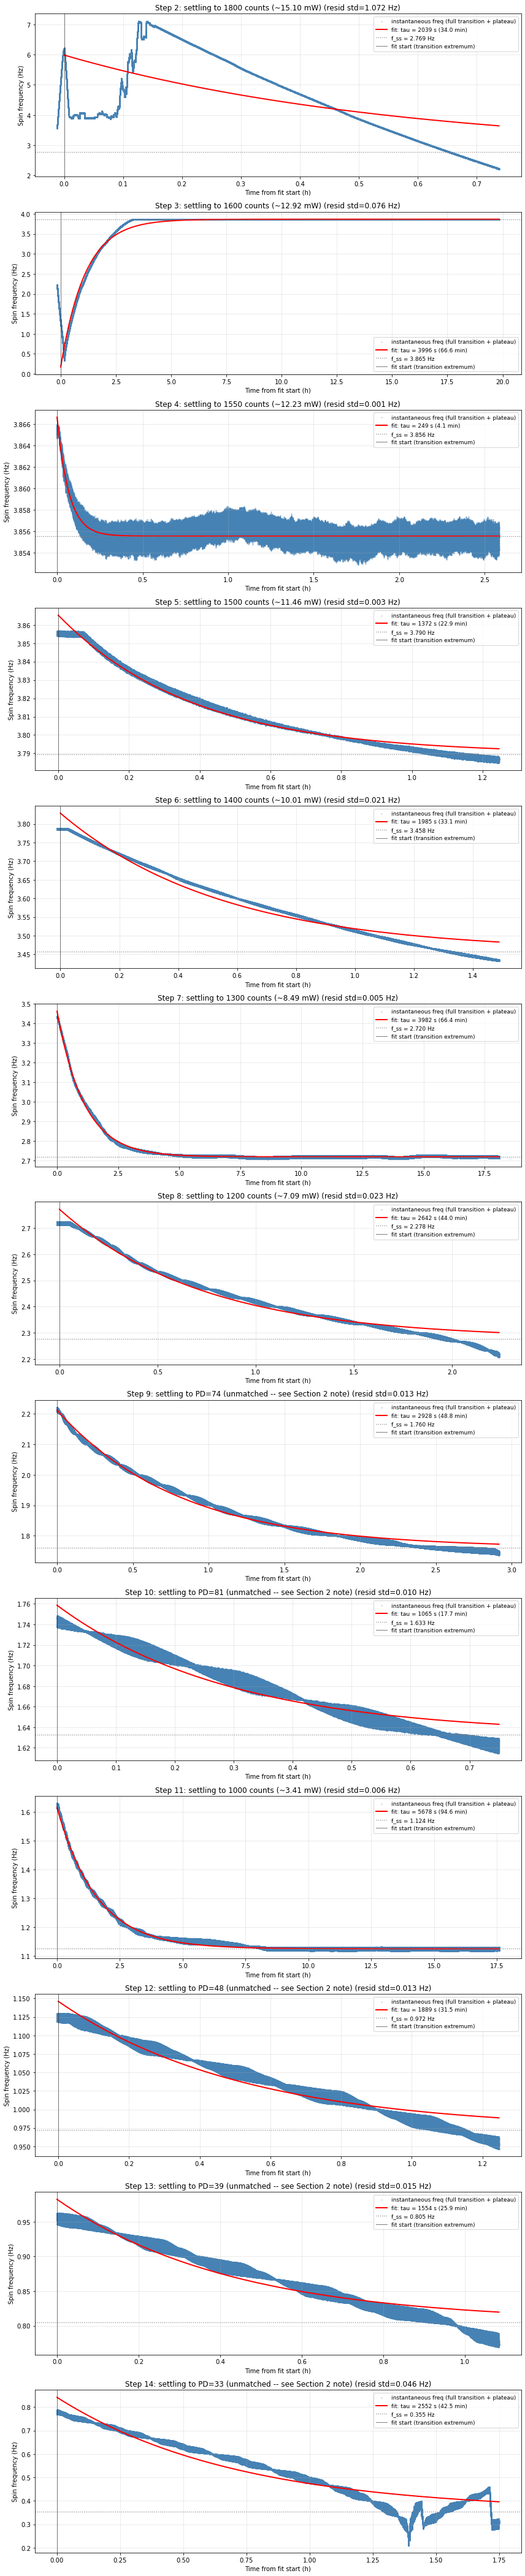

In [9]:
n = len(fit_results)
fig, axes = plt.subplots(n, 1, figsize=(12, 4.5 * n))
if n == 1:
    axes = [axes]

for ax, r in zip(axes, fit_results):
    i = r['step']
    prev, cur = steps[i - 1], steps[i]
    plot_mask = (t_freq_yaw >= prev['t_end_gps']) & (t_freq_yaw <= cur['t_end_gps'])
    t_plot_h = (t_freq_yaw[plot_mask] - r['t_fit_start']) / 3600.0
    ax.scatter(t_plot_h, freq_yaw[plot_mask], s=2, alpha=0.25, color='steelblue',
               label='instantaneous freq (full transition + plateau)')

    ts_fit = np.linspace(0, r['t_fit_end'] - r['t_fit_start'], 1000)
    ax.plot(ts_fit / 3600.0, exp_decay_ss(ts_fit, r['A'], r['gamma'], r['f_ss']), 'r-',
            linewidth=2, label=f"fit: tau = {r['tau']:.0f} s ({r['tau']/60:.1f} min)")
    ax.axhline(r['f_ss'], color='gray', linestyle=':', linewidth=1.2,
               label=f"f_ss = {r['f_ss']:.3f} Hz")
    ax.axvline(0, color='black', linewidth=1, alpha=0.5, label='fit start (transition extremum)')

    ax.set_xlabel('Time from fit start (h)')
    ax.set_ylabel('Spin frequency (Hz)')
    ax.set_title(f"Step {i}: settling to {step_label(i, cur)} "
                 f"(resid std={r['resid_std']:.3f} Hz)")
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.5. Cross-Check: Wide-Band PSD + PIT Agreement at Each Steady State
Motivation: the Hilbert-transform `f_ss` values above come from a signal that was
narrowly bandpassed before the Hilbert transform, which can hide problems. The first
version of this section (with the old `F_HIGH=3.0 Hz`) found the wide-band dominant
peak for several steps (1800/1600/1550/1500 counts) sitting well above that cutoff --
2.3-3.9 Hz -- meaning the Hilbert transform had been tracking filter leakage, not the
real signal, for those steps.

That was cross-checked against the **independent PIT channel** (a different readout
axis of the same disk): PIT and YAW agreed on the dominant frequency to within the
PSD's own bin resolution at every single step, including the previously-mismatched
ones -- strong evidence those peaks are real rotation, not a YAW-specific artifact.
`F_HIGH` was widened to 6.0 Hz in Section 3 to stop clipping them.

This section now re-runs as an ongoing sanity check with the corrected filter: for
each step, pull a short **unfiltered** window from both YAW and PIT raw data (128 s
segments x 5 non-overlapping averages = 640 s, from the end of each plateau), and
confirm `f_ss` still lines up with the dominant peak in both channels. Note on the
"half frequency at slow spin" question raised earlier: checking the sub-harmonic
against each step's *own* dominant peak (not a possibly-wrong `f_ss`) shows small,
fairly flat ratios across steps (a few percent, no dramatic jump) -- the single large
ratio seen before turned out to be an artifact of checking the wrong reference
frequency, not a real effect. That's noted here rather than re-asserted as a finding,
since it didn't hold up under the more careful check.

In [10]:
from scipy.signal import welch

def load_channel_window(files, gps_t0, gps_t1, fs_out=64.0):
    """Decimated read restricted to [gps_t0, gps_t1] -- targeted, not the whole file."""
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            dec  = int(round(fs / fs_out))
            for gps0, ix, n in zip(segs, idxs, lens):
                gps1 = gps0 + n / fs
                if gps1 < gps_t0 or gps0 > gps_t1:
                    continue
                seg = dset[ix:ix + n].astype(np.float64)
                if dec == 16:
                    seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)
                elif dec > 1:
                    seg = decimate(seg, dec, zero_phase=True)
                t_seg = gps0 + np.arange(len(seg)) / fs_out
                mask = (t_seg >= gps_t0) & (t_seg <= gps_t1)
                t_list.append(t_seg[mask]); y_list.append(seg[mask])
    if not t_list:
        return np.array([]), np.array([])
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

PSD_SEG_S  = 128        # segment length
PSD_NAVG   = 5           # non-overlapping averages
PSD_WIN_S  = PSD_SEG_S * PSD_NAVG   # 640 s total window, taken from the plateau's end
CROSS_CHANNEL_TOL = 0.02  # Hz -- YAW/PIT global peaks within this are "agreeing"

def global_peak(freqs, psd, band=(0.05, 10)):
    m = (freqs > band[0]) & (freqs < band[1])
    j = np.argmax(psd[m])
    return freqs[m][j], psd[m][j]

def peak_near(freqs, psd, f_center, halfwidth=0.05):
    m = (freqs >= f_center - halfwidth) & (freqs <= f_center + halfwidth)
    if m.sum() == 0:
        return None, None
    j = np.argmax(psd[m])
    return freqs[m][j], psd[m][j]

psd_results = []
for r in fit_results:
    i, f_ss = r['step'], r['f_ss']
    cur = steps[i]
    t1 = cur['t_end_gps']
    t0 = t1 - PSD_WIN_S

    t_yw, y_yw = load_channel_window(YAW_FILES, t0, t1, fs_out=FS_RING)
    t_pt, y_pt = load_channel_window(PIT_FILES, t0, t1, fs_out=FS_RING)
    if len(y_yw) < PSD_WIN_S * FS_RING * 0.9 or len(y_pt) < PSD_WIN_S * FS_RING * 0.9:
        print(f"Step {i}: insufficient data for PSD snapshot -- skipped")
        continue
    y_yw = y_yw - y_yw.mean()
    y_pt = y_pt - y_pt.mean()
    freqs, psd_yw = welch(y_yw, fs=FS_RING, nperseg=int(PSD_SEG_S * FS_RING), noverlap=0,
                          scaling='density')
    _, psd_pt = welch(y_pt, fs=FS_RING, nperseg=int(PSD_SEG_S * FS_RING), noverlap=0,
                       scaling='density')

    f_global, p_global = global_peak(freqs, psd_yw)
    f_global_pit, p_global_pit = global_peak(freqs, psd_pt)
    f_half, p_half = peak_near(freqs, psd_yw, f_global / 2)
    ratio_half = (p_half / p_global) if (p_half is not None and p_global > 0) else np.nan

    flags = []
    if abs(f_global - f_ss) > 0.1:
        flags.append("MISMATCH: f_ss far from wide-band peak")
    if abs(f_global - f_global_pit) > CROSS_CHANNEL_TOL:
        flags.append("YAW/PIT DISAGREE")
    if ratio_half is not None and ratio_half > 0.3:
        flags.append("sub-harmonic comparable to fundamental")

    psd_results.append(dict(step=i, f_ss=f_ss, freqs=freqs, psd=psd_yw, psd_pit=psd_pt,
                             f_global=f_global, p_global=p_global,
                             f_global_pit=f_global_pit,
                             f_half=f_half, p_half=p_half, ratio_half=ratio_half,
                             flags=flags))
    flag_str = ("  <-- " + "; ".join(flags)) if flags else ""
    print(f"Step {i:2d} ({step_label(i, cur)}): f_ss={f_ss:.4f} Hz, "
          f"YAW peak @ {f_global:.4f} Hz, PIT peak @ {f_global_pit:.4f} Hz, "
          f"sub-harmonic/fundamental ratio = {ratio_half:.3f}{flag_str}")

Step  2 (1800 counts (~15.10 mW)): f_ss=2.7688 Hz, YAW peak @ 2.3359 Hz, PIT peak @ 2.3359 Hz, sub-harmonic/fundamental ratio = 0.029  <-- MISMATCH: f_ss far from wide-band peak
Step  3 (1600 counts (~12.92 mW)): f_ss=3.8652 Hz, YAW peak @ 3.8672 Hz, PIT peak @ 3.8672 Hz, sub-harmonic/fundamental ratio = 0.015
Step  4 (1550 counts (~12.23 mW)): f_ss=3.8555 Hz, YAW peak @ 3.8516 Hz, PIT peak @ 3.8516 Hz, sub-harmonic/fundamental ratio = 0.021
Step  5 (1500 counts (~11.46 mW)): f_ss=3.7896 Hz, YAW peak @ 3.7891 Hz, PIT peak @ 3.7891 Hz, sub-harmonic/fundamental ratio = 0.013
Step  6 (1400 counts (~10.01 mW)): f_ss=3.4581 Hz, YAW peak @ 3.4453 Hz, PIT peak @ 3.4453 Hz, sub-harmonic/fundamental ratio = 0.022
Step  7 (1300 counts (~8.49 mW)): f_ss=2.7195 Hz, YAW peak @ 2.7188 Hz, PIT peak @ 2.7188 Hz, sub-harmonic/fundamental ratio = 0.016
Step  8 (1200 counts (~7.09 mW)): f_ss=2.2777 Hz, YAW peak @ 2.2578 Hz, PIT peak @ 2.2578 Hz, sub-harmonic/fundamental ratio = 0.026
Step  9 (PD=74 (unma

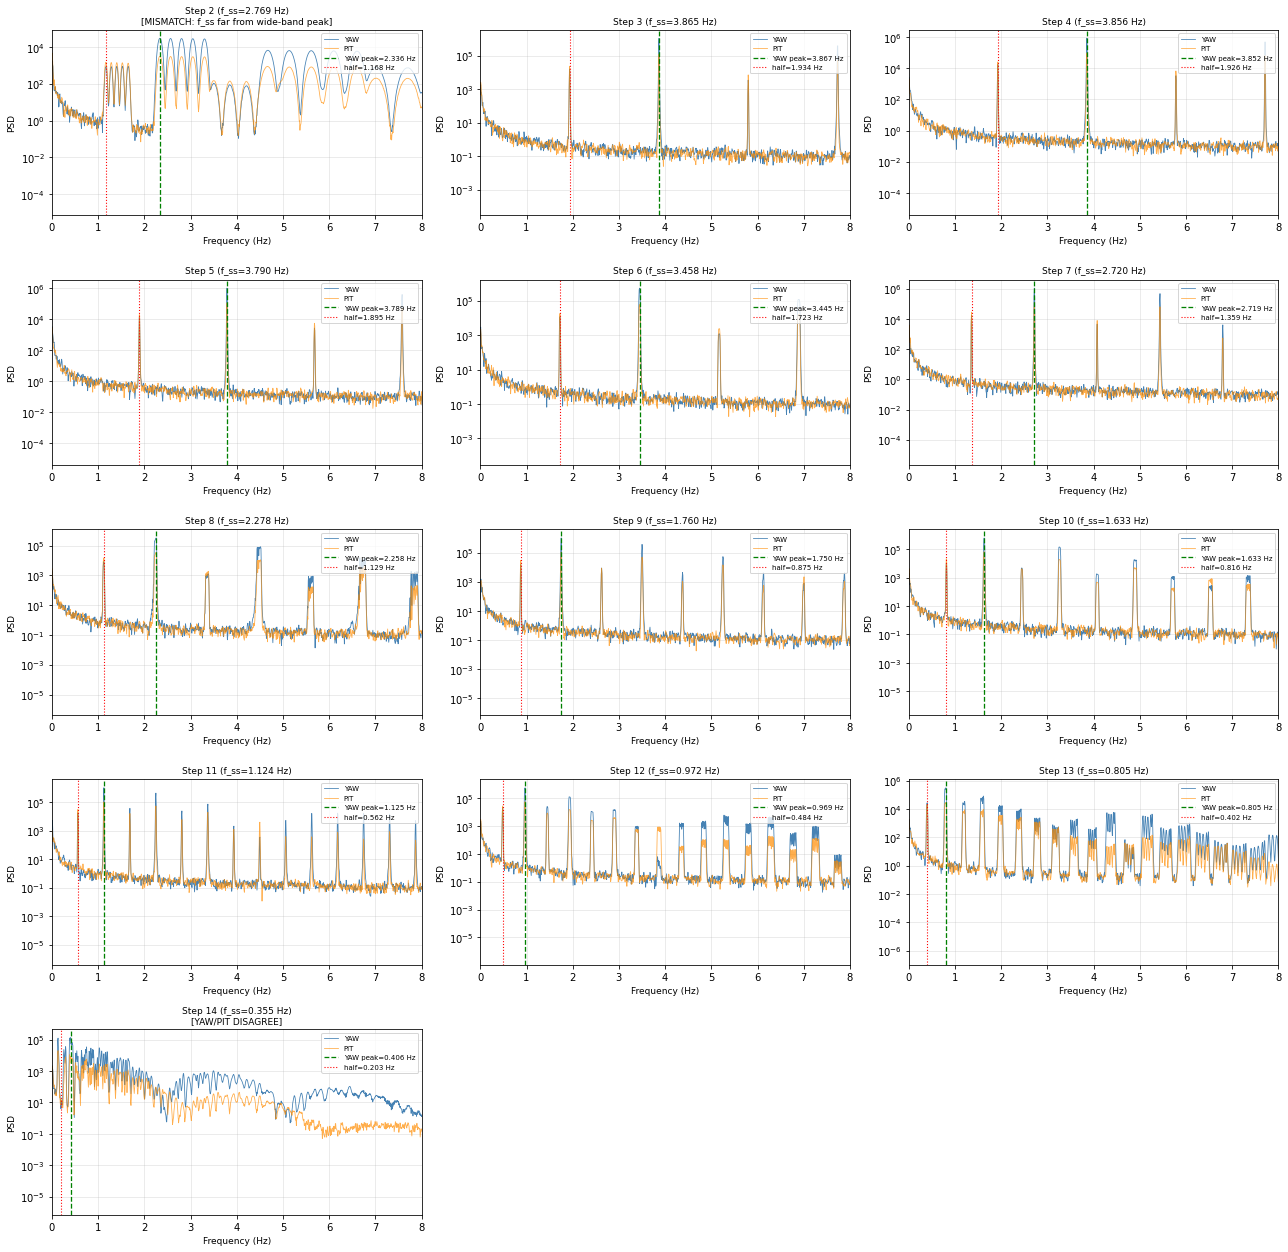

In [11]:
n = len(psd_results)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, pr in zip(axes, psd_results):
    ax.semilogy(pr['freqs'], pr['psd'], color='steelblue', linewidth=0.8, label='YAW')
    ax.semilogy(pr['freqs'], pr['psd_pit'], color='darkorange', linewidth=0.8, alpha=0.7, label='PIT')
    ax.axvline(pr['f_global'], color='green', linestyle='--', linewidth=1.3,
               label=f"YAW peak={pr['f_global']:.3f} Hz")
    ax.axvline(pr['f_global'] / 2, color='red', linestyle=':', linewidth=1.1,
               label=f"half={pr['f_global']/2:.3f} Hz")
    ax.set_xlim(0, 8)
    title = f"Step {pr['step']} (f_ss={pr['f_ss']:.3f} Hz)"
    if pr['flags']:
        title += "\n[" + ", ".join(pr['flags']) + "]"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    ax.set_ylabel('PSD', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
print("=" * 105)
print("PSD CROSS-CHECK SUMMARY (post F_HIGH fix)")
print("=" * 105)
print(f"{'step':>4} | {'f_ss (Hz)':>10} | {'YAW peak':>9} | {'PIT peak':>9} | {'sub-harm ratio':>15} | flags")
for pr in psd_results:
    flag_str = "; ".join(pr['flags']) if pr['flags'] else "-"
    print(f"{pr['step']:>4} | {pr['f_ss']:>10.4f} | {pr['f_global']:>9.4f} | {pr['f_global_pit']:>9.4f} | "
          f"{pr['ratio_half']:>15.3f} | {flag_str}")

n_ok = sum(1 for pr in psd_results if not pr['flags'])
print(f"\n{n_ok}/{len(psd_results)} steps: f_ss matches the wide-band peak in both YAW and PIT, "
      "with no comparably-sized sub-harmonic.")
print("Remaining flags (if any) are printed above for individual follow-up rather than assumed away.")

PSD CROSS-CHECK SUMMARY (post F_HIGH fix)
step |  f_ss (Hz) |  YAW peak |  PIT peak |  sub-harm ratio | flags
   2 |     2.7688 |    2.3359 |    2.3359 |           0.029 | MISMATCH: f_ss far from wide-band peak
   3 |     3.8652 |    3.8672 |    3.8672 |           0.015 | -
   4 |     3.8555 |    3.8516 |    3.8516 |           0.021 | -
   5 |     3.7896 |    3.7891 |    3.7891 |           0.013 | -
   6 |     3.4581 |    3.4453 |    3.4453 |           0.022 | -
   7 |     2.7195 |    2.7188 |    2.7188 |           0.016 | -
   8 |     2.2777 |    2.2578 |    2.2578 |           0.026 | -
   9 |     1.7598 |    1.7500 |    1.7500 |           0.014 | -
  10 |     1.6329 |    1.6328 |    1.6328 |           0.017 | -
  11 |     1.1244 |    1.1250 |    1.1250 |           0.017 | -
  12 |     0.9724 |    0.9688 |    0.9688 |           0.037 | -
  13 |     0.8053 |    0.8047 |    0.8047 |           0.086 | -
  14 |     0.3548 |    0.4062 |    0.1328 |           0.063 | YAW/PIT DISAGREE

11/13

## 5. Results Summary
Saves the detected step table (needed by `laser_stepdown_stability.ipynb`) alongside
the settling-fit results.

In [13]:
print("=" * 90)
print("LASER STEP-DOWN SETTLING RESULTS")
print("=" * 90)
print(f"{'step':>4} | {'level':>26} | {'f_ss (Hz)':>10} | {'tau (min)':>12} | {'resid std':>10} | pts")
for r in fit_results:
    cur = steps[r['step']]
    print(f"{r['step']:>4} | {step_label(r['step'], cur):>26} | {r['f_ss']:>10.4f} | "
          f"{r['tau']/60:>7.2f} +/- {r['tau_err']/60:>4.2f} | {r['resid_std']:>10.4f} | {r['n_points']}")

worst = max(fit_results, key=lambda r: r['resid_std'])
print(f"\nNote: step {worst['step']} ({step_label(worst['step'], steps[worst['step']])}) has"
      f" the largest residual std ({worst['resid_std']:.4f} Hz) of all fitted steps --"
      " the two highest-power\nsteps (1800, 1600 counts) show a persistent oscillation"
      " around their mean the whole time\nthey're held, unlike the very quiet mid/low-power"
      " steps. That's real dynamics the single-\nexponential model doesn't capture, not a fit"
      " problem -- worth a closer look separately.")

# Save step table (+ fit results where available) for the stability/PSD notebook
with open(STEP_TABLE_CSV, 'w', newline='') as fcsv:
    writer = csv.writer(fcsv)
    writer.writerow(['step', 'pd_level', 'counts', 'power_mw', 't_start_gps', 't_end_gps',
                      'duration_h', 'f_ss_hz', 'tau_s', 'tau_err_s'])
    fit_by_step = {r['step']: r for r in fit_results}
    for i, s in enumerate(steps):
        r = fit_by_step.get(i)
        info = STEP_LOG_INFO.get(i, {})
        writer.writerow([
            i, s['pd_level'], info.get('counts', ''), info.get('power_mw', ''),
            s['t_start_gps'], s['t_end_gps'], s['duration_h'],
            r['f_ss'] if r else '', r['tau'] if r else '', r['tau_err'] if r else '',
        ])
print(f"\nSaved step table -> {STEP_TABLE_CSV}")

LASER STEP-DOWN SETTLING RESULTS
step |                      level |  f_ss (Hz) |    tau (min) |  resid std | pts
   2 |    1800 counts (~15.10 mW) |     2.7688 |   33.98 +/- 0.14 |     1.0716 | 169164
   3 |    1600 counts (~12.92 mW) |     3.8652 |   66.59 +/- 0.01 |     0.0757 | 4546795
   4 |    1550 counts (~12.23 mW) |     3.8555 |    4.14 +/- 0.01 |     0.0008 | 592165
   5 |    1500 counts (~11.46 mW) |     3.7896 |   22.86 +/- 0.01 |     0.0026 | 285745
   6 |    1400 counts (~10.01 mW) |     3.4581 |   33.08 +/- 0.02 |     0.0205 | 341254
   7 |     1300 counts (~8.49 mW) |     2.7195 |   66.37 +/- 0.00 |     0.0055 | 4145558
   8 |     1200 counts (~7.09 mW) |     2.2777 |   44.03 +/- 0.02 |     0.0229 | 512986
   9 | PD=74 (unmatched -- see Section 2 note) |     1.7598 |   48.81 +/- 0.01 |     0.0126 | 668640
  10 | PD=81 (unmatched -- see Section 2 note) |     1.6329 |   17.75 +/- 0.02 |     0.0097 | 171936
  11 |     1000 counts (~3.41 mW) |     1.1244 |   94.63 +/- 0.01 